In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_csv("social_media_usage.csv")
df.head()

,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21


In [7]:
#Calculate the correlation
df_insta=df[df['App']=='Instagram']
df_facebook=df[df['App']=='Facebook']
corr_overall=df[['Daily_Minutes_Spent','Posts_Per_Day']].corr()
corr_insta=df_insta[['Daily_Minutes_Spent','Posts_Per_Day']].corr()
corr_facebook=df_facebook[['Daily_Minutes_Spent','Posts_Per_Day']].corr()

In [8]:
#calculate the covariance
cov_overall=df[['Daily_Minutes_Spent','Posts_Per_Day']].cov()
cov_insta=df_insta[['Daily_Minutes_Spent','Posts_Per_Day']].cov()
cov_facebook=df_facebook[['Daily_Minutes_Spent','Posts_Per_Day']].cov()

In [9]:
print(corr_overall,corr_insta,corr_facebook)
print()
print(cov_overall,cov_insta,cov_facebook)

                     Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent             1.000000      -0.023968
Posts_Per_Day                  -0.023968       1.000000                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent             1.000000      -0.075716
Posts_Per_Day                  -0.075716       1.000000                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent              1.00000       -0.05709
Posts_Per_Day                   -0.05709        1.00000

                     Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         21424.739315     -21.476468
Posts_Per_Day                 -21.476468      37.476115                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         22820.392806     -67.486331
Posts_Per_Day                 -67.486331      34.812127                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         23610.052669     -56.051906
Posts_Per_Day                 -56.051906      4

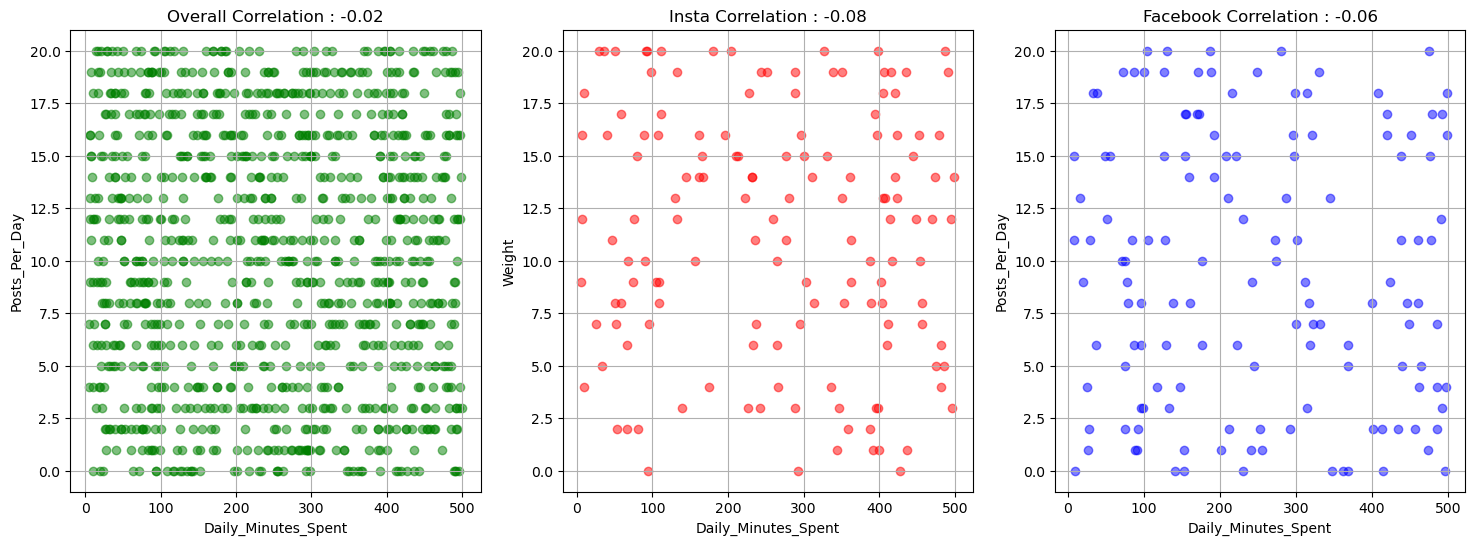

In [14]:
fig,axes= plt.subplots(1,3,figsize=(18,6))
axes[0].scatter(df['Daily_Minutes_Spent'],df['Posts_Per_Day'],color='green',alpha=0.5)
axes[0].set_title(f'Overall Correlation : {corr_overall.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[0].set_xlabel('Daily_Minutes_Spent')
axes[0].set_ylabel('Posts_Per_Day')
axes[0].grid(True)

#Instagram data plot
axes[1].scatter(df_insta['Daily_Minutes_Spent'],df_insta['Posts_Per_Day'],color='red',alpha=0.5)
axes[1].set_title(f'Insta Correlation : {corr_insta.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[1].set_xlabel('Daily_Minutes_Spent')
axes[1].set_ylabel('Weight')
axes[1].grid(True)


#Facebook data plot
axes[2].scatter(df_facebook['Daily_Minutes_Spent'],df_facebook['Posts_Per_Day'],color='blue',alpha=0.5)
axes[2].set_title(f'Facebook Correlation : {corr_facebook.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[2].set_xlabel('Daily_Minutes_Spent')
axes[2].set_ylabel('Posts_Per_Day')
axes[2].grid(True)



In [15]:
#Combine 3 datasets then do the analysis on "Official time" and "pace" draw the scatter plot and the heatmap
df_2015=pd.read_csv("marathon_results_2015.csv")
df_2016=pd.read_csv("marathon_results_2016.csv")
df_2017=pd.read_csv("marathon_results_2017.csv")


In [17]:
df_c=pd.concat([df_2015,df_2016,df_2017])
df_c.head()

,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Unnamed: 8
0,0.0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:32:00,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1,NaN
1,1.0,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:31:59,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2,NaN
2,2.0,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:32:00,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3,NaN
3,3.0,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:32:00,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4,NaN
4,4.0,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:32:00,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5,NaN


In [24]:
df_c['Official Time']=pd.to_timedelta(df_c['Official Time'])
df_c['Pace']=pd.to_timedelta(df_c['Pace'])
corr=df_c[['Pace','Official Time']].corr()
cov=df_c[['Pace','Official Time']].cov()
print(corr)
print()
print(cov)

                   Pace  Official Time
Pace           1.000000       0.999667
Official Time  0.999667       1.000000

                       Pace  Official Time
Pace           9.042173e+21   2.369121e+23
Official Time  2.369121e+23   6.211420e+24


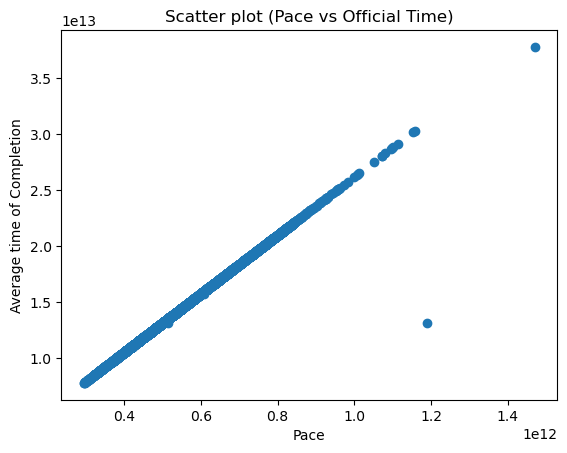

In [26]:
plt.plot(figsize=(18,6))
plt.scatter(df_c['Pace'],df_c['Official Time'])
plt.xlabel('Pace')
plt.ylabel('Average time of Completion')
plt.title('Scatter plot (Pace vs Official Time)')
plt.show()



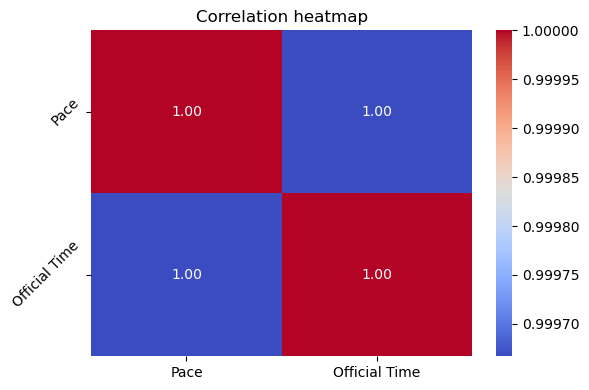

In [28]:
#plotting the heatmap
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation heatmap")
plt.yticks(rotation=45)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()